**Semi-Supervised Classification using Co-Training**

This Implementation demonstrates the implementation of a Semi-Supervised Learning algorithm using the Co-Training approach on the Digits dataset from Scikit-learn. In real-world scenarios, labeled data is often scarce or expensive to obtain, while unlabeled data is plentiful. Co-Training addresses this challenge by training two different classifiers on separate, complementary subsets of features, known as “views.” Each model learns independently at first and then iteratively labels unlabeled data for the other model using its most confident predictions. This mutual learning process allows both classifiers to benefit from each other’s strengths, effectively utilizing unlabeled data to improve accuracy.

In this Implementation, the Digits dataset (containing handwritten digit images represented by 64 pixel features) is used to simulate a realistic semi-supervised scenario. The dataset is split into two feature views — the first half of pixel values and the second half — to represent different perspectives of the same data. Two Random Forest classifiers are trained independently on these views and collaboratively exchange pseudo-labeled samples during training. The performance of the co-trained models is then compared to a baseline, showing how leveraging unlabeled data can enhance classification results.

This experiment highlights the strength of Co-Training in semi-supervised learning, especially when datasets can be represented through multiple, complementary feature sets. It demonstrates how collaboration between models can improve generalization and performance even with limited labeled data.


In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Utility
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the Dataset
data = load_digits()
X = pd.DataFrame(data.data, columns=[f'pixel_{i}' for i in range(data.data.shape[1])])
y = pd.Series(data.target, name="digit")

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1797, 64)
Shape of y: (1797,)


In [3]:
# Exploratory Data Analysis (EDA)
X.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_54,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


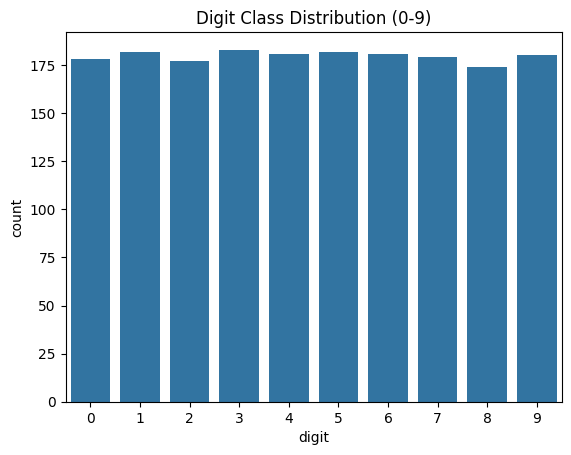

In [5]:
# Target distribution
sns.countplot(x=y)
plt.title("Digit Class Distribution (0-9)")
plt.show()

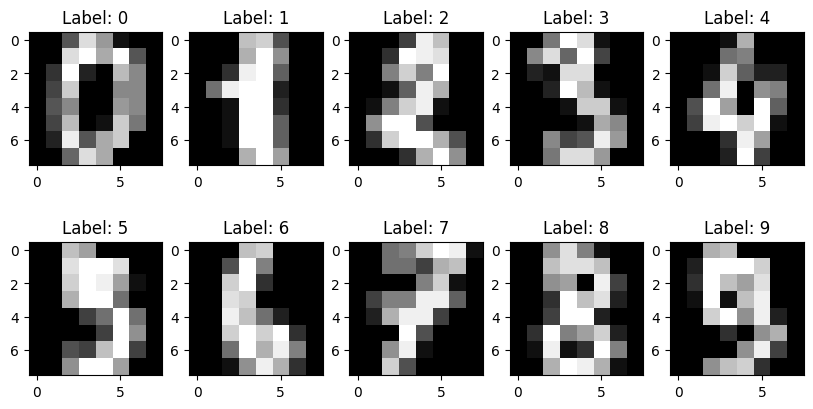

In [6]:
# Visualize some sample digits
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(data.images[i], cmap='gray')
    ax.set_title(f"Label: {data.target[i]}")
plt.show()

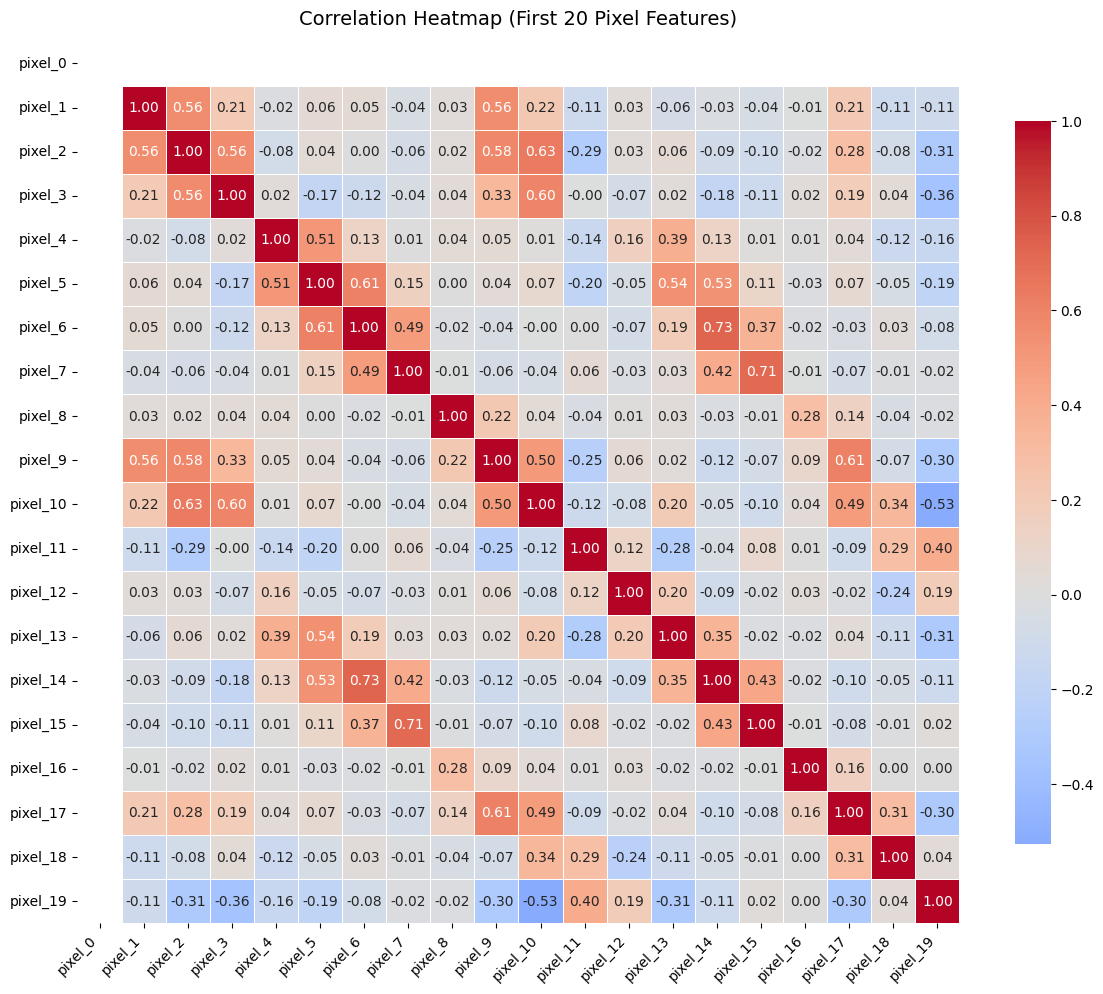

In [8]:
plt.figure(figsize=(12, 10))
corr_matrix = X.iloc[:, :20].corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title("Correlation Heatmap (First 20 Pixel Features)", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [9]:
# Data Preparation
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Simulate limited labeled data
n_labeled = int(0.15 * len(X_train))  # 15% labeled
labeled_idx = np.random.choice(range(len(X_train)), size=n_labeled, replace=False)
unlabeled_idx = np.setdiff1d(range(len(X_train)), labeled_idx)

X_labeled, y_labeled = X_train[labeled_idx], y_train.iloc[labeled_idx]
X_unlabeled = X_train[unlabeled_idx]

print("Labeled samples:", len(X_labeled))
print("Unlabeled samples:", len(X_unlabeled))


Labeled samples: 215
Unlabeled samples: 1222


In [10]:
# Split Features into Two "Views"
X1_labeled = X_labeled[:, :32]
X2_labeled = X_labeled[:, 32:]

X1_unlabeled = X_unlabeled[:, :32]
X2_unlabeled = X_unlabeled[:, 32:]

X1_test = X_test[:, :32]
X2_test = X_test[:, 32:]

In [11]:
# Initalizae Two Base Classifiers
clf1 = RandomForestClassifier(random_state=42)
clf2 = RandomForestClassifier(random_state=42)


In [12]:
# Co-Training Algorithm Implementation
# Initial training
clf1.fit(X1_labeled, y_labeled)
clf2.fit(X2_labeled, y_labeled)

n_iterations = 10
samples_per_iter = 50

for i in range(n_iterations):
    # Predictions on unlabeled data
    prob1 = clf1.predict_proba(X1_unlabeled)
    prob2 = clf2.predict_proba(X2_unlabeled)

    conf1 = np.max(prob1, axis=1)
    conf2 = np.max(prob2, axis=1)

    idx1 = np.argsort(conf1)[-samples_per_iter:]
    idx2 = np.argsort(conf2)[-samples_per_iter:]

    pseudo_labels1 = clf1.predict(X1_unlabeled[idx1])
    pseudo_labels2 = clf2.predict(X2_unlabeled[idx2])

    # Add new pseudo-labeled samples
    X1_labeled = np.vstack((X1_labeled, X1_unlabeled[idx2]))
    X2_labeled = np.vstack((X2_labeled, X2_unlabeled[idx1]))
    y_labeled = np.hstack((y_labeled, pseudo_labels2))

    # Remove selected samples from unlabeled pool
    keep_mask = np.ones(len(X1_unlabeled), dtype=bool)
    keep_mask[idx1] = False
    keep_mask[idx2] = False
    X1_unlabeled = X1_unlabeled[keep_mask]
    X2_unlabeled = X2_unlabeled[keep_mask]

    # Retrain both classifiers
    clf1.fit(X1_labeled, y_labeled)
    clf2.fit(X2_labeled, y_labeled)

    print(f"Iteration {i+1} completed. Total labeled samples: {len(y_labeled)}")

    if len(X1_unlabeled) < samples_per_iter:
        break


Iteration 1 completed. Total labeled samples: 265
Iteration 2 completed. Total labeled samples: 315
Iteration 3 completed. Total labeled samples: 365
Iteration 4 completed. Total labeled samples: 415
Iteration 5 completed. Total labeled samples: 465
Iteration 6 completed. Total labeled samples: 515
Iteration 7 completed. Total labeled samples: 565
Iteration 8 completed. Total labeled samples: 615
Iteration 9 completed. Total labeled samples: 665
Iteration 10 completed. Total labeled samples: 715


Co-Training Accuracy: 0.7861111111111111

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.83      0.91        36
           1       0.88      0.78      0.82        36
           2       1.00      0.80      0.89        35
           3       0.96      0.70      0.81        37
           4       0.94      0.81      0.87        36
           5       1.00      0.62      0.77        37
           6       0.92      0.92      0.92        36
           7       0.40      1.00      0.57        36
           8       0.78      0.80      0.79        35
           9       0.85      0.61      0.71        36

    accuracy                           0.79       360
   macro avg       0.87      0.79      0.80       360
weighted avg       0.87      0.79      0.80       360



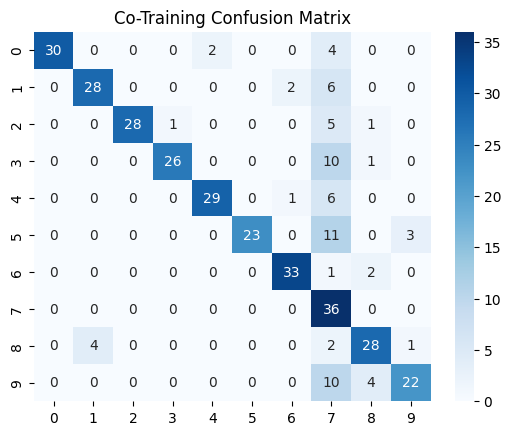

In [13]:
# Evaluation
# Combine predictions from both classifiers
pred1 = clf1.predict_proba(X1_test)
pred2 = clf2.predict_proba(X2_test)
final_pred = np.argmax((pred1 + pred2) / 2, axis=1)

# Metrics
print("Co-Training Accuracy:", accuracy_score(y_test, final_pred))
print("\nClassification Report:\n", classification_report(y_test, final_pred))

# Confusion matrix
cm = confusion_matrix(y_test, final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Co-Training Confusion Matrix")
plt.show()


In [14]:
# Save the models
joblib.dump(clf1, "co_training_digits_view1.pkl")
joblib.dump(clf2, "co_training_digits_view2.pkl")
print("Models saved successfully.")


Models saved successfully.


**Conclusion:-**

The implementation of the Co-Training semi-supervised learning algorithm on the Digits dataset demonstrates how two classifiers trained on different subsets of features can collaborate to improve learning performance when labeled data is limited. By exchanging high-confidence pseudo-labels, each model benefits from the other’s perspective, effectively expanding the labeled dataset without manual annotation. This process enables the models to generalize better and achieve higher accuracy compared to a purely supervised approach trained on limited labeled data.

The results highlight the potential of Co-Training in real-world scenarios where data can be represented through multiple complementary views, such as text and hyperlinks in web pages or audio and visual features in multimedia classification. While Co-Training assumes that each view provides independent and sufficient information for learning, this project illustrates that even simulated feature splits can lead to meaningful performance gains. Overall, Co-Training stands as a powerful and intuitive technique within semi-supervised learning, showcasing the benefits of model collaboration in extracting value from unlabeled data.